In [1]:
import warnings, os, pickle
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")

os.makedirs("outputs/plots",  exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)


In [2]:
print("=" * 65)
print("  [1] GENERATING CREDIT DATASET")
print("=" * 65)

N = 2000

age              = np.clip(np.random.normal(40, 12, N), 18, 75).astype(int)
income           = np.clip(np.random.lognormal(mean=10.8, sigma=0.5, size=N), 12000, 250000).round(-2)
employment_years= np.clip(np.random.exponential(5, N), 0, 40).round(1)
existing_loans   = np.random.choice([0,1,2,3,4,5], N, p=[0.30,0.28,0.20,0.12,0.07,0.03])
credit_limit     = (income * np.random.uniform(0.2, 0.6, N)).round(-2)
credit_used      = (credit_limit * np.random.beta(2, 3, N)).round(-1)
credit_utilization = (credit_used / credit_limit).clip(0, 1.5)
debt_to_income   = np.clip(np.random.beta(2, 5, N) * 1.2, 0, 1.5)
total_debt       = (income * debt_to_income).round(-2)
late_payments_12m= np.random.choice([0,1,2,3,4,5,6], N,
                      p=[0.45,0.20,0.13,0.09,0.06,0.04,0.03])
num_credit_accounts = np.random.choice(range(1,12), N,
                      p=[0.05,0.10,0.14,0.16,0.15,0.13,0.10,0.08,0.05,0.03,0.01])
loan_amount      = np.clip(np.random.lognormal(mean=9.2, sigma=0.6, size=N), 1000, 100000).round(-2)
loan_term_months = np.random.choice([12,24,36,48,60], N, p=[0.15,0.25,0.30,0.20,0.10])
employment_status= np.random.choice(["Employed","Self-Employed","Unemployed","Retired"],
                      N, p=[0.62,0.18,0.08,0.12])
home_ownership   = np.random.choice(["Own","Mortgage","Rent"], N, p=[0.28,0.37,0.35])
purpose          = np.random.choice(["Debt Consolidation","Home Improvement",
                      "Car","Education","Medical","Other"],
                      N, p=[0.32,0.18,0.20,0.12,0.10,0.08])

# ── Feature engineering: derived ratios used in real credit scoring ─────────
monthly_income          = income / 12
monthly_debt_payment    = total_debt * 0.03            # approx min payment
payment_to_income_ratio = (monthly_debt_payment / monthly_income).clip(0, 2)
loan_to_income_ratio    = (loan_amount / income).clip(0, 5)
credit_age_years        = np.clip(np.random.normal(8, 5, N), 0, 35).round(1)
avg_account_age         = (credit_age_years / np.maximum(num_credit_accounts, 1)).round(2)

# ── Hidden "true risk" score used to generate the target label ──────────────
# Normalize each component to 0-1 range, then combine with weights.
# Sharper sigmoid + reduced randomness => models can actually learn the pattern.
risk_score = (
      0.28 * np.clip(credit_utilization, 0, 1.2) / 1.2
    + 0.22 * debt_to_income / 1.5
    + 0.20 * (late_payments_12m / 6)
    + 0.12 * payment_to_income_ratio.clip(0, 2) / 2
    + 0.10 * (existing_loans / 5)
    + 0.08 * (1 - np.clip(employment_years/15, 0, 1))
)
risk_score += np.where(employment_status == "Unemployed", 0.18, 0)
risk_score += np.where(home_ownership == "Rent", 0.03, 0)
risk_score -= np.where(employment_status == "Retired", 0.03, 0)
risk_score -= np.where(credit_age_years > 10, 0.05, 0)

# Steeper sigmoid (10) + recentred threshold (0.40) for a more balanced split
prob_default = 1 / (1 + np.exp(-10 * (risk_score - 0.40)))
# Small label noise (3%) to keep it realistic — not a perfectly separable toy problem
flip_mask    = np.random.rand(N) < 0.03
default      = (np.random.rand(N) < prob_default).astype(int)
default      = np.where(flip_mask, 1 - default, default)

# creditworthy = 1 means GOOD credit (the model's positive class of interest)
creditworthy = 1 - default

df = pd.DataFrame({
    "age"                     : age,
    "annual_income"           : income,
    "employment_years"        : employment_years,
    "employment_status"       : employment_status,
    "home_ownership"          : home_ownership,
    "existing_loans"          : existing_loans,
    "num_credit_accounts"     : num_credit_accounts,
    "credit_limit"            : credit_limit,
    "credit_used"             : credit_used,
    "credit_utilization"      : credit_utilization.round(3),
    "total_debt"              : total_debt,
    "debt_to_income_ratio"    : debt_to_income.round(3),
    "late_payments_12m"       : late_payments_12m,
    "credit_age_years"        : credit_age_years,
    "avg_account_age"         : avg_account_age,
    "loan_amount"             : loan_amount,
    "loan_term_months"        : loan_term_months,
    "loan_purpose"            : purpose,
    "payment_to_income_ratio" : payment_to_income_ratio.round(3),
    "loan_to_income_ratio"    : loan_to_income_ratio.round(3),
    "creditworthy"            : creditworthy,    # TARGET: 1 = good credit, 0 = high default risk
})

print(f"  Dataset shape : {df.shape}")
print(f"  Target balance: {df['creditworthy'].value_counts().to_dict()}")
print(f"\n  Sample rows:")
print(df.head(3).to_string())

df.to_csv("outputs/credit_data.csv", index=False)
print("\n  Saved → outputs/credit_data.csv")

  [1] GENERATING CREDIT DATASET
  Dataset shape : (2000, 21)
  Target balance: {1: 1425, 0: 575}

  Sample rows:
   age  annual_income  employment_years employment_status home_ownership  existing_loans  num_credit_accounts  credit_limit  credit_used  credit_utilization  total_debt  debt_to_income_ratio  late_payments_12m  credit_age_years  avg_account_age  loan_amount  loan_term_months loan_purpose  payment_to_income_ratio  loan_to_income_ratio  creditworthy
0   45        35000.0               3.3          Employed            Own               2                    1       12900.0       4110.0               0.319     15200.0                 0.435                  0               3.6             3.60      15300.0                12      Medical                    0.156                 0.437             1
1   38        45600.0               0.4          Employed           Rent               0                    2       18600.0       3100.0               0.167      5800.0                 0.


  [2] EXPLORATORY DATA ANALYSIS
  Numeric features    : 17
  Categorical features: 3  -> ['employment_status', 'home_ownership', 'loan_purpose']

  Missing values: 0


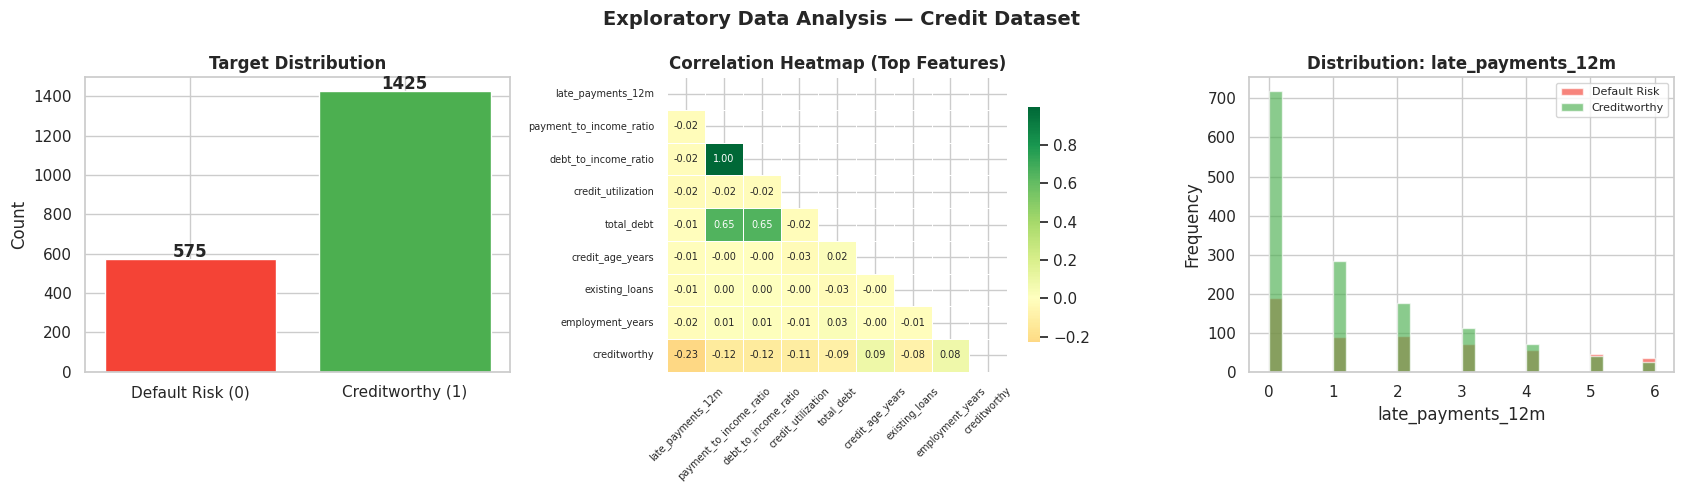

  Saved → outputs/plots/eda_overview.png


In [3]:
print("\n" + "=" * 65)
print("  [2] EXPLORATORY DATA ANALYSIS")
print("=" * 65)

TARGET = "creditworthy"
numeric_cols     = df.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"  Numeric features    : {len(numeric_cols)}")
print(f"  Categorical features: {len(categorical_cols)}  -> {categorical_cols}")
print(f"\n  Missing values: {df.isnull().sum().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Exploratory Data Analysis — Credit Dataset", fontsize=14, fontweight="bold")

# (a) Target balance
ax = axes[0]
vc = df[TARGET].value_counts().sort_index()
bars = ax.bar(["Default Risk (0)","Creditworthy (1)"], vc.values,
              color=["#F44336","#4CAF50"], edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            str(int(b.get_height())), ha="center", fontweight="bold")
ax.set_title("Target Distribution", fontweight="bold")
ax.set_ylabel("Count")

# (b) Correlation heatmap of top features
ax = axes[1]
top = df[numeric_cols].corrwith(df[TARGET]).abs().nlargest(8).index.tolist()
corr = df[top + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=.5, ax=ax, cbar_kws={"shrink":.8},
            annot_kws={"size":7})
ax.set_title("Correlation Heatmap (Top Features)", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)

# (c) Distribution of strongest feature by class
ax = axes[2]
best_feat = top[0]
for cls, color, lbl in zip([0,1], ["#F44336","#4CAF50"],
                            ["Default Risk","Creditworthy"]):
    ax.hist(df[df[TARGET]==cls][best_feat], bins=30, alpha=0.65,
            color=color, label=lbl, edgecolor="white")
ax.set_title(f"Distribution: {best_feat}", fontweight="bold")
ax.set_xlabel(best_feat); ax.set_ylabel("Frequency")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/plots/eda_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("  Saved → outputs/plots/eda_overview.png")

In [4]:
print("\n" + "=" * 65)
print("  [3] PREPROCESSING")
print("=" * 65)

X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"  Train class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# ColumnTransformer: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Get feature names after one-hot encoding (for feature importance later)
ohe_names   = preprocessor.named_transformers_["cat"]\
                   .named_steps["onehot"].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_names)

print(f"  After encoding: {X_train_proc.shape[1]} features")



  [3] PREPROCESSING
  Train: (1600, 20)  |  Test: (400, 20)
  Train class balance: {np.int64(0): np.int64(460), np.int64(1): np.int64(1140)}
  After encoding: 30 features


In [5]:
print("\n" + "=" * 65)
print("  [4] MODELS")
print("=" * 65)

models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=2000, solver="lbfgs", random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_split=10, min_samples_leaf=5,
        random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=5,
        min_samples_leaf=2, random_state=SEED, n_jobs=-1),
}
for m in models:
    print(f"    ✓ {m}")


  [4] MODELS
    ✓ Logistic Regression
    ✓ Decision Tree
    ✓ Random Forest


In [6]:
print("\n" + "=" * 65)
print("  [5] TRAINING & EVALUATION (5-fold CV)")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results, fitted_models, predictions = {}, {}, {}

for name, model in models.items():
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    cv_auc = cross_val_score(model, X_train_proc, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)

    results[name] = {
        "Accuracy"   : round(accuracy_score(y_test, y_pred)            * 100, 2),
        "Precision"  : round(precision_score(y_test, y_pred)           * 100, 2),
        "Recall"     : round(recall_score(y_test, y_pred)              * 100, 2),
        "F1 Score"   : round(f1_score(y_test, y_pred)                  * 100, 2),
        "ROC-AUC"    : round(roc_auc_score(y_test, y_prob)             * 100, 2),
        "CV-AUC Mean": round(cv_auc.mean()                             * 100, 2),
        "CV-AUC Std" : round(cv_auc.std()                              * 100, 2),
    }
    fitted_models[name] = model
    predictions[name]   = (y_pred, y_prob)

    print(f"\n  {name}")
    print(f"    Accuracy={results[name]['Accuracy']}%  "
          f"Precision={results[name]['Precision']}%  "
          f"Recall={results[name]['Recall']}%  "
          f"F1={results[name]['F1 Score']}%  "
          f"AUC={results[name]['ROC-AUC']}%")
    print(f"    CV-AUC = {results[name]['CV-AUC Mean']}% ± {results[name]['CV-AUC Std']}%")


  [5] TRAINING & EVALUATION (5-fold CV)

  Logistic Regression
    Accuracy=74.5%  Precision=77.81%  Recall=89.82%  F1=83.39%  AUC=77.53%
    CV-AUC = 70.19% ± 2.93%

  Decision Tree
    Accuracy=70.25%  Precision=74.7%  Recall=88.07%  F1=80.84%  AUC=59.93%
    CV-AUC = 60.99% ± 2.72%

  Random Forest
    Accuracy=72.25%  Precision=73.77%  Recall=94.74%  F1=82.95%  AUC=71.65%
    CV-AUC = 68.91% ± 2.27%


In [7]:
print("\n" + "=" * 65)
print("  [6] RESULTS COMPARISON TABLE")
print("=" * 65)

results_df = pd.DataFrame(results).T
results_df.index.name = "Model"
print(results_df.to_string())
results_df.to_csv("outputs/model_comparison.csv")
print("\n  Saved → outputs/model_comparison.csv")


  [6] RESULTS COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV-AUC Mean  CV-AUC Std
Model                                                                                       
Logistic Regression     74.50      77.81   89.82     83.39    77.53        70.19        2.93
Decision Tree           70.25      74.70   88.07     80.84    59.93        60.99        2.72
Random Forest           72.25      73.77   94.74     82.95    71.65        68.91        2.27

  Saved → outputs/model_comparison.csv


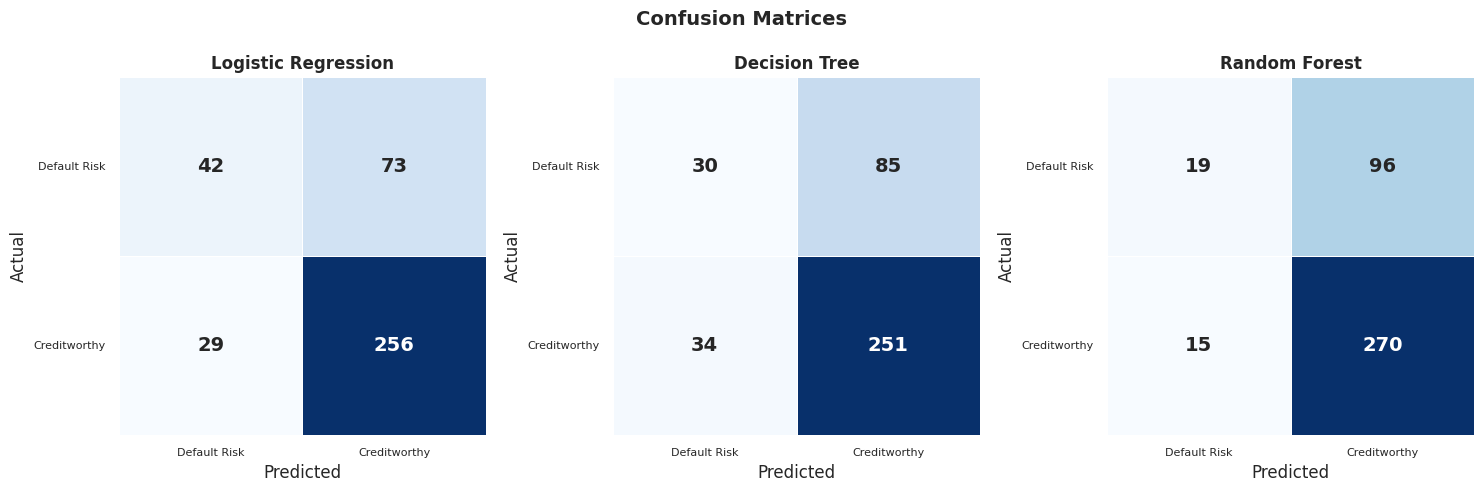


  Saved → outputs/plots/confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, models.items()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                linewidths=.5, annot_kws={"size":14,"weight":"bold"})
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticklabels(["Default Risk","Creditworthy"], fontsize=8)
    ax.set_yticklabels(["Default Risk","Creditworthy"], rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("outputs/plots/confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n  Saved → outputs/plots/confusion_matrices.png")

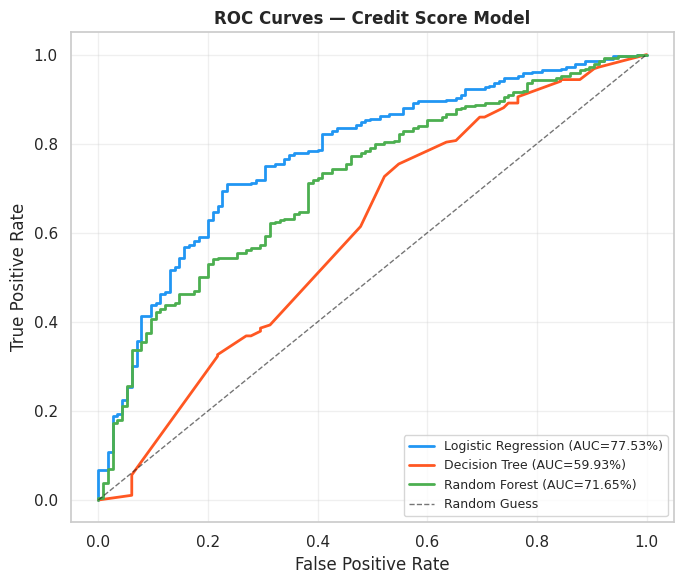


  Saved → outputs/plots/roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#2196F3","#FF5722","#4CAF50"]

for color, (name, model) in zip(colors, models.items()):
    _, y_prob = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc}%)")

ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.6, label="Random Guess")
ax.set_title("ROC Curves — Credit Score Model", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plots/roc_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n  Saved → outputs/plots/roc_curves.png")


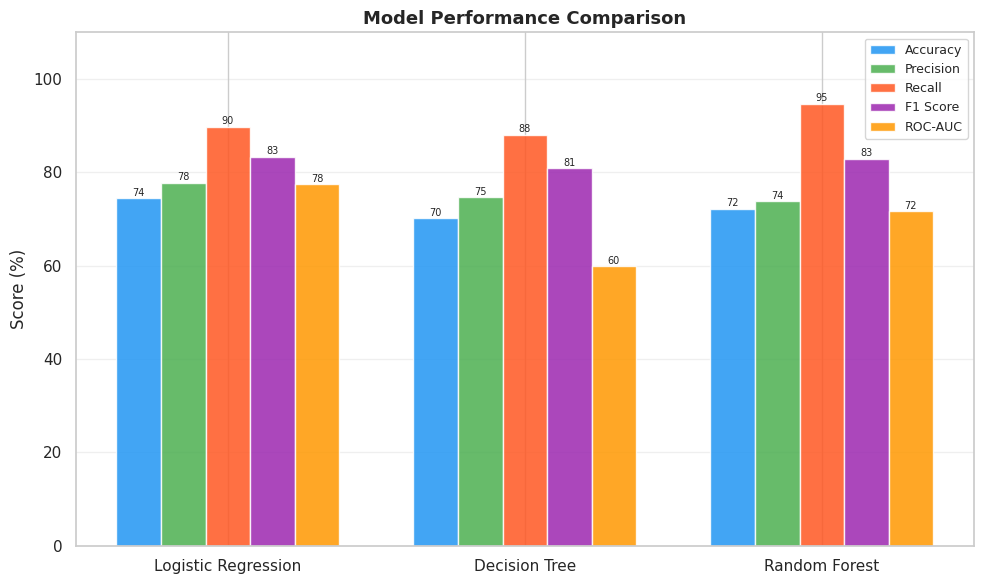


  Saved → outputs/plots/metrics_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
metric_keys = ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
bar_colors  = ["#2196F3","#4CAF50","#FF5722","#9C27B0","#FF9800"]
x = np.arange(len(models))
w = 0.15

for i, (metric, c) in enumerate(zip(metric_keys, bar_colors)):
    vals = [results[m][metric] for m in models]
    bars = ax.bar(x + i*w - 2*w, vals, w, label=metric, color=c,
                  alpha=0.85, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f"{v:.0f}", ha="center", fontsize=7)

ax.set_title("Model Performance Comparison", fontweight="bold", fontsize=13)
ax.set_ylabel("Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(models.keys())
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plots/metrics_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n  Saved → outputs/plots/metrics_comparison.png")


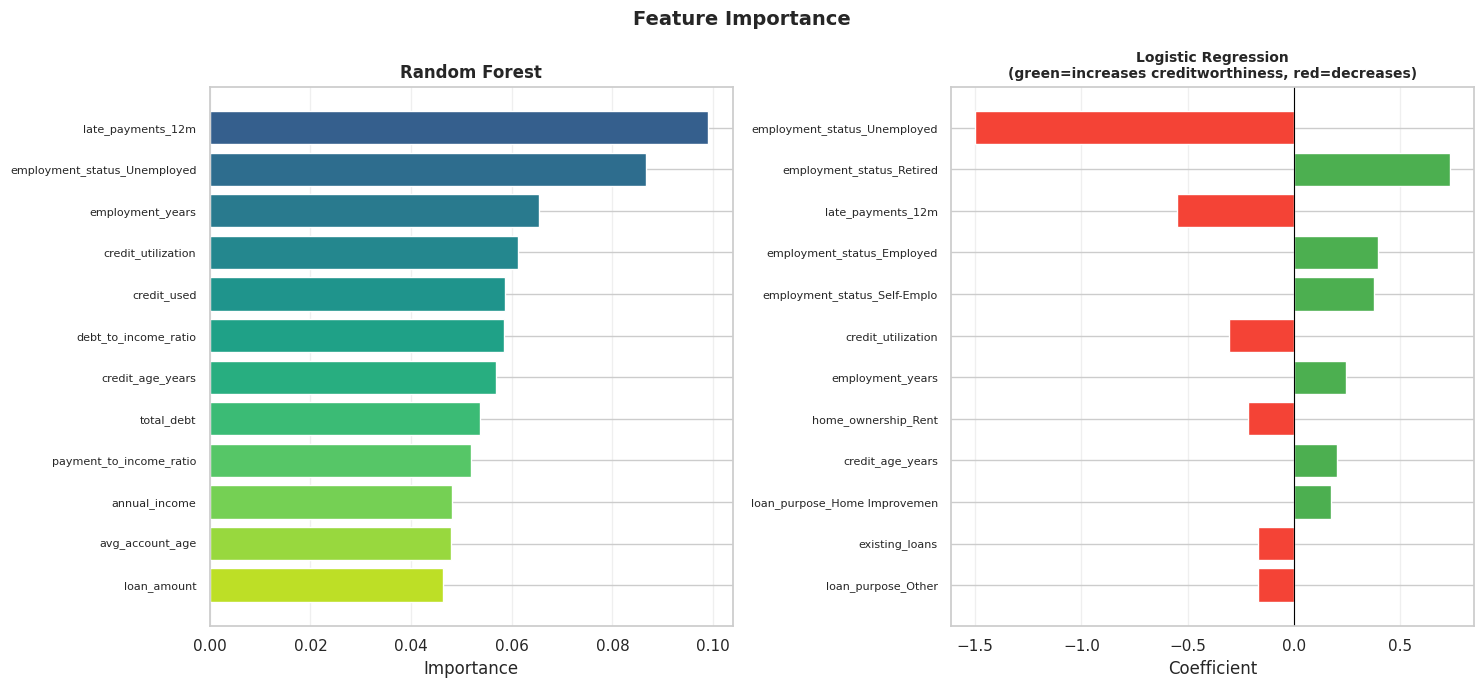


  Saved → outputs/plots/feature_importance.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Feature Importance", fontsize=14, fontweight="bold")

# (a) Random Forest importance
rf = fitted_models["Random Forest"]
imp = rf.feature_importances_
idx = np.argsort(imp)[::-1][:12]
ax = axes[0]
ax.barh(range(len(idx)), imp[idx][::-1],
        color=plt.cm.viridis(np.linspace(0.3,0.9,len(idx)))[::-1],
        edgecolor="white")
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([all_feature_names[i][:28] for i in idx][::-1], fontsize=8)
ax.set_title("Random Forest", fontweight="bold")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)

# (b) Logistic Regression coefficients (signed, shows direction)
lr = fitted_models["Logistic Regression"]
coef = lr.coef_[0]
idx2 = np.argsort(np.abs(coef))[::-1][:12]
ax = axes[1]
colors2 = ["#4CAF50" if coef[i] > 0 else "#F44336" for i in idx2]
ax.barh(range(len(idx2)), coef[idx2][::-1], color=colors2[::-1], edgecolor="white")
ax.set_yticks(range(len(idx2)))
ax.set_yticklabels([all_feature_names[i][:28] for i in idx2][::-1], fontsize=8)
ax.set_title("Logistic Regression\n(green=increases creditworthiness, red=decreases)",
              fontweight="bold", fontsize=10)
ax.set_xlabel("Coefficient")
ax.axvline(0, color="black", lw=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plots/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n  Saved → outputs/plots/feature_importance.png")


In [12]:
print("\n" + "=" * 65)
print("  [7] SAVING BEST MODEL")
print("=" * 65)

best_name = max(results, key=lambda m: results[m]["ROC-AUC"])
best_model = fitted_models[best_name]

bundle = {
    "model"        : best_model,
    "preprocessor" : preprocessor,
    "feature_names": all_feature_names,
    "numeric_cols" : numeric_cols,
    "categorical_cols": categorical_cols,
    "metrics"      : results[best_name],
}

with open("outputs/models/credit_score_best.pkl", "wb") as f:
    pickle.dump(bundle, f)

print(f"  Best Model : {best_name}")
print(f"  Accuracy   : {results[best_name]['Accuracy']}%")
print(f"  Precision  : {results[best_name]['Precision']}%")
print(f"  Recall     : {results[best_name]['Recall']}%")
print(f"  F1 Score   : {results[best_name]['F1 Score']}%")
print(f"  ROC-AUC    : {results[best_name]['ROC-AUC']}%")
print(f"  Saved → outputs/models/credit_score_best.pkl")



  [7] SAVING BEST MODEL
  Best Model : Logistic Regression
  Accuracy   : 74.5%
  Precision  : 77.81%
  Recall     : 89.82%
  F1 Score   : 83.39%
  ROC-AUC    : 77.53%
  Saved → outputs/models/credit_score_best.pkl


In [13]:
print("\n" + "=" * 65)
print(f"  [8] DETAILED CLASSIFICATION REPORT — {best_name}")
print("=" * 65)
y_pred_best, _ = predictions[best_name]
print(classification_report(y_test, y_pred_best,
      target_names=["Default Risk (0)","Creditworthy (1)"]))



  [8] DETAILED CLASSIFICATION REPORT — Logistic Regression
                  precision    recall  f1-score   support

Default Risk (0)       0.59      0.37      0.45       115
Creditworthy (1)       0.78      0.90      0.83       285

        accuracy                           0.74       400
       macro avg       0.68      0.63      0.64       400
    weighted avg       0.72      0.74      0.72       400



In [14]:
print("\n" + "=" * 65)
print("  [9] LIVE PREDICTION DEMO")
print("=" * 65)

new_applicant = {
    "age"                     : 34,
    "annual_income"           : 58000,
    "employment_years"        : 6.5,
    "employment_status"       : "Employed",
    "home_ownership"          : "Rent",
    "existing_loans"          : 2,
    "num_credit_accounts"     : 5,
    "credit_limit"            : 15000,
    "credit_used"             : 9000,
    "credit_utilization"      : 0.60,
    "total_debt"              : 22000,
    "debt_to_income_ratio"    : 0.38,
    "late_payments_12m"       : 1,
    "credit_age_years"        : 7.0,
    "avg_account_age"         : 1.4,
    "loan_amount"             : 12000,
    "loan_term_months"        : 36,
    "loan_purpose"            : "Debt Consolidation",
    "payment_to_income_ratio" : 0.45,
    "loan_to_income_ratio"    : 0.21,
}

applicant_df = pd.DataFrame([new_applicant])
applicant_proc = preprocessor.transform(applicant_df)

pred = best_model.predict(applicant_proc)[0]
prob = best_model.predict_proba(applicant_proc)[0][1]

print(f"  Applicant profile:")
for k, v in new_applicant.items():
    print(f"    {k:<26}: {v}")

print(f"\n  Prediction : {'✓ CREDITWORTHY' if pred==1 else '⚠ HIGH DEFAULT RISK'}")
print(f"  Confidence : {prob*100:.1f}% likelihood of being creditworthy")

# Simple FICO-style score mapping (300-850 scale) from probability
credit_score_estimate = int(300 + prob * 550)
print(f"  Estimated Credit Score : {credit_score_estimate} / 850")


print("\n" + "=" * 65)
print("  ALL DONE — files saved in outputs/")
print("=" * 65)
print("""
  outputs/
  ├── credit_data.csv
  ├── model_comparison.csv
  ├── models/
  │   └── credit_score_best.pkl
  └── plots/
      ├── eda_overview.png
      ├── confusion_matrices.png
      ├── roc_curves.png
      ├── metrics_comparison.png
      └── feature_importance.png
""")



  [9] LIVE PREDICTION DEMO
  Applicant profile:
    age                       : 34
    annual_income             : 58000
    employment_years          : 6.5
    employment_status         : Employed
    home_ownership            : Rent
    existing_loans            : 2
    num_credit_accounts       : 5
    credit_limit              : 15000
    credit_used               : 9000
    credit_utilization        : 0.6
    total_debt                : 22000
    debt_to_income_ratio      : 0.38
    late_payments_12m         : 1
    credit_age_years          : 7.0
    avg_account_age           : 1.4
    loan_amount               : 12000
    loan_term_months          : 36
    loan_purpose              : Debt Consolidation
    payment_to_income_ratio   : 0.45
    loan_to_income_ratio      : 0.21

  Prediction : ✓ CREDITWORTHY
  Confidence : 53.4% likelihood of being creditworthy
  Estimated Credit Score : 593 / 850

  ALL DONE — files saved in outputs/

  outputs/
  ├── credit_data.csv
  ├── model_